In [2]:
import pickle
warehouses = {}
for wh in ["oe", "of", "rt"]:
    with open(f"/Users/betsyfrdmn/Lucas_Systems_Capstone_Project/Model_Betsy_Conan/results_{wh}.pkl", "rb") as f:
        warehouses[wh.upper()] = pickle.load(f)

print("Loaded:", list(warehouses.keys()))
for wh, data in warehouses.items():
    print(f"{wh}: WorkCodes = {data['WORKCODES']}")

Loaded: ['OE', 'OF', 'RT']
OE: WorkCodes = ['10', '20', '30']
OF: WorkCodes = ['10', '20', '30']
RT: WorkCodes = ['1', '11', '13', '14', '15', '2', '3', '4', '5', '6', 'nan']


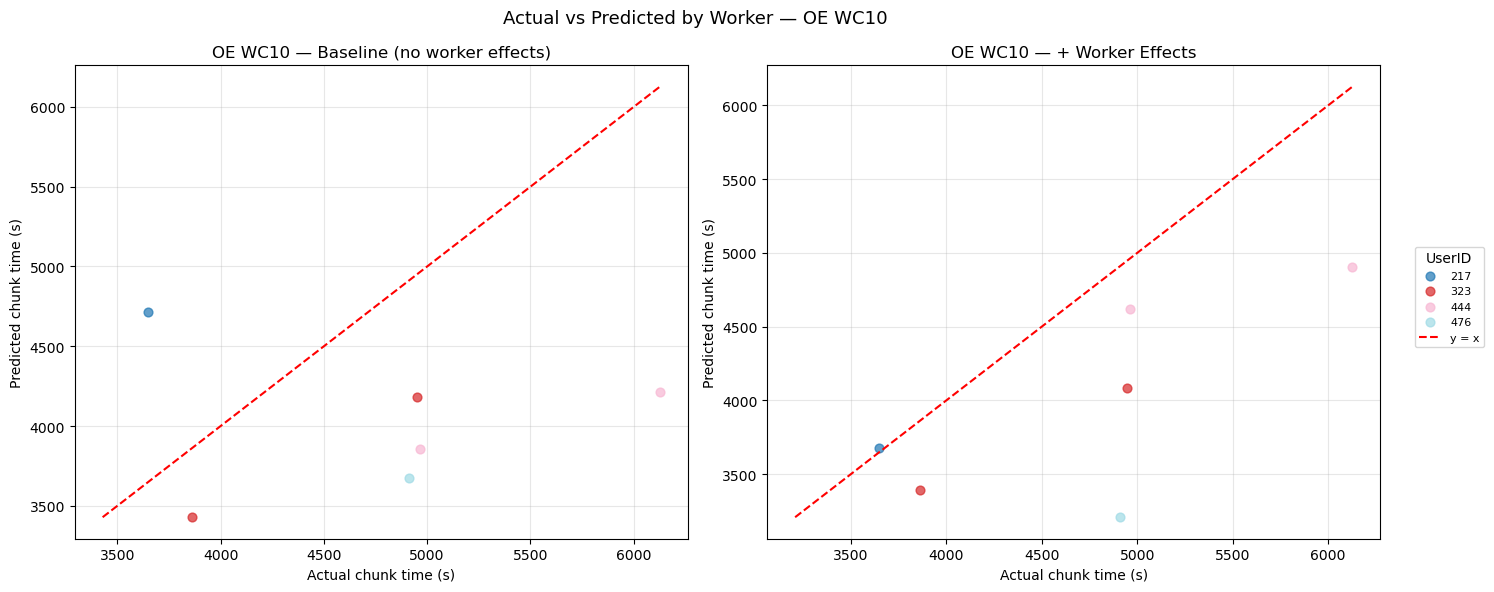

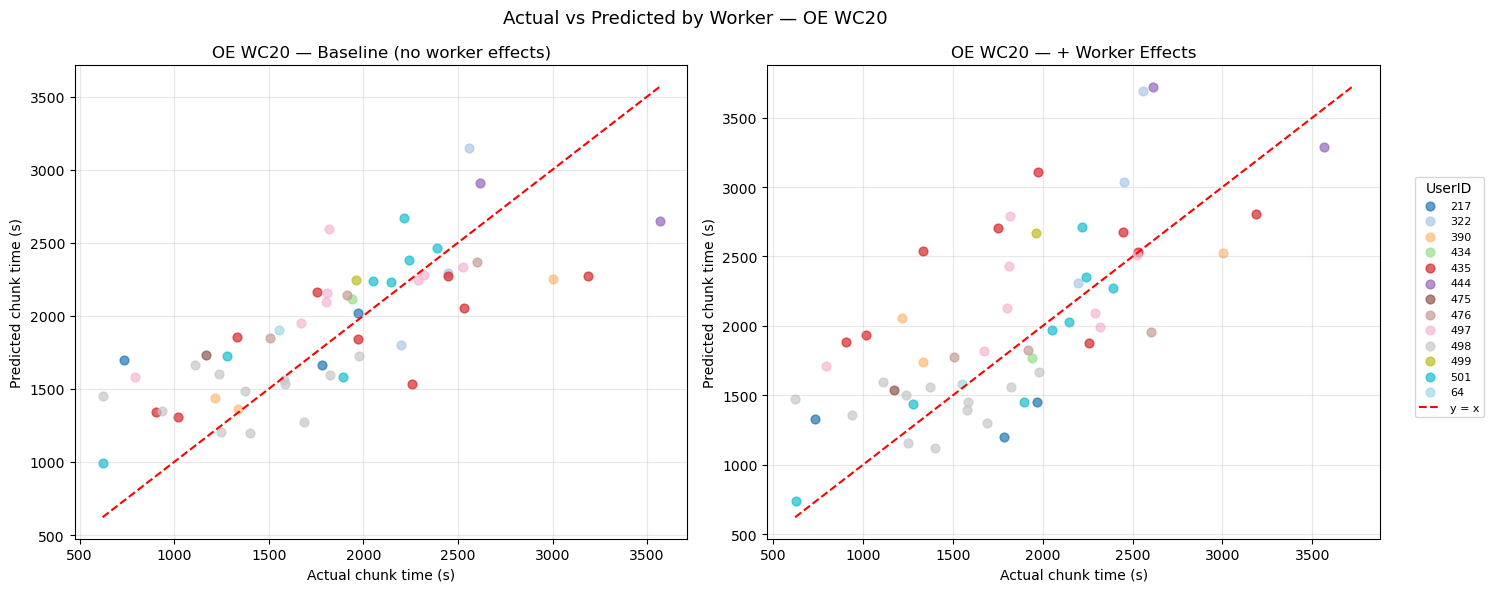

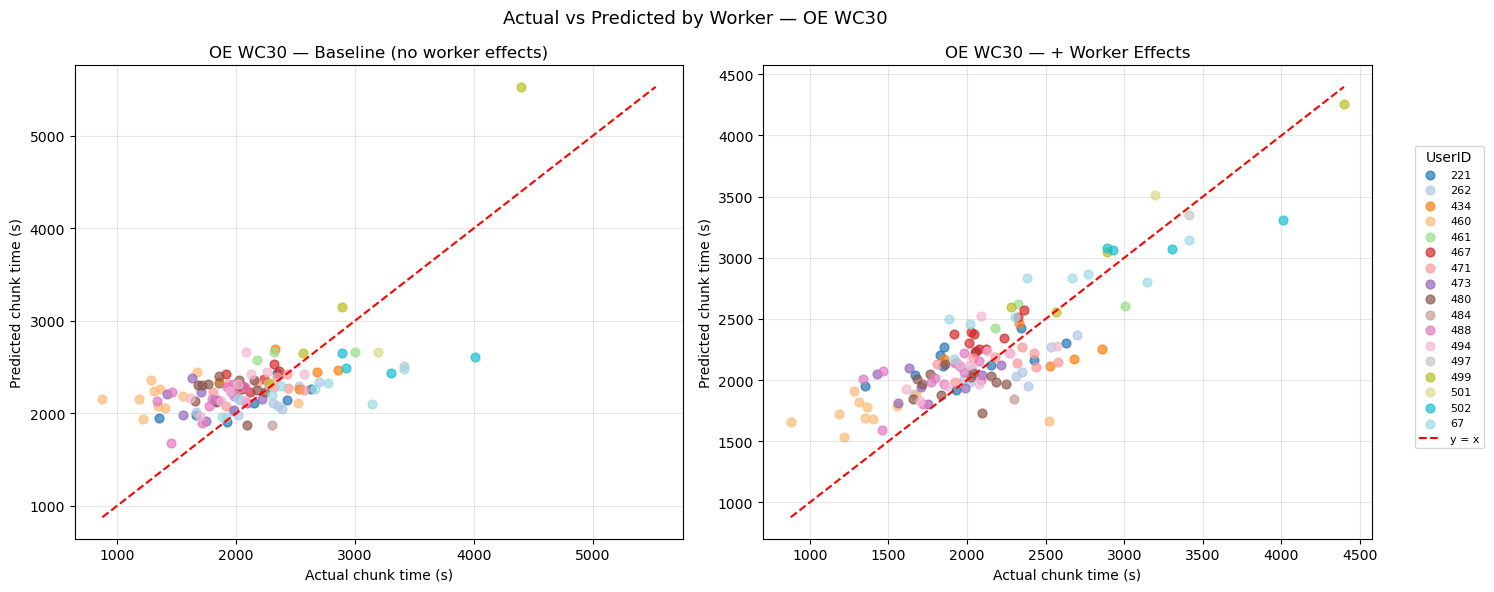

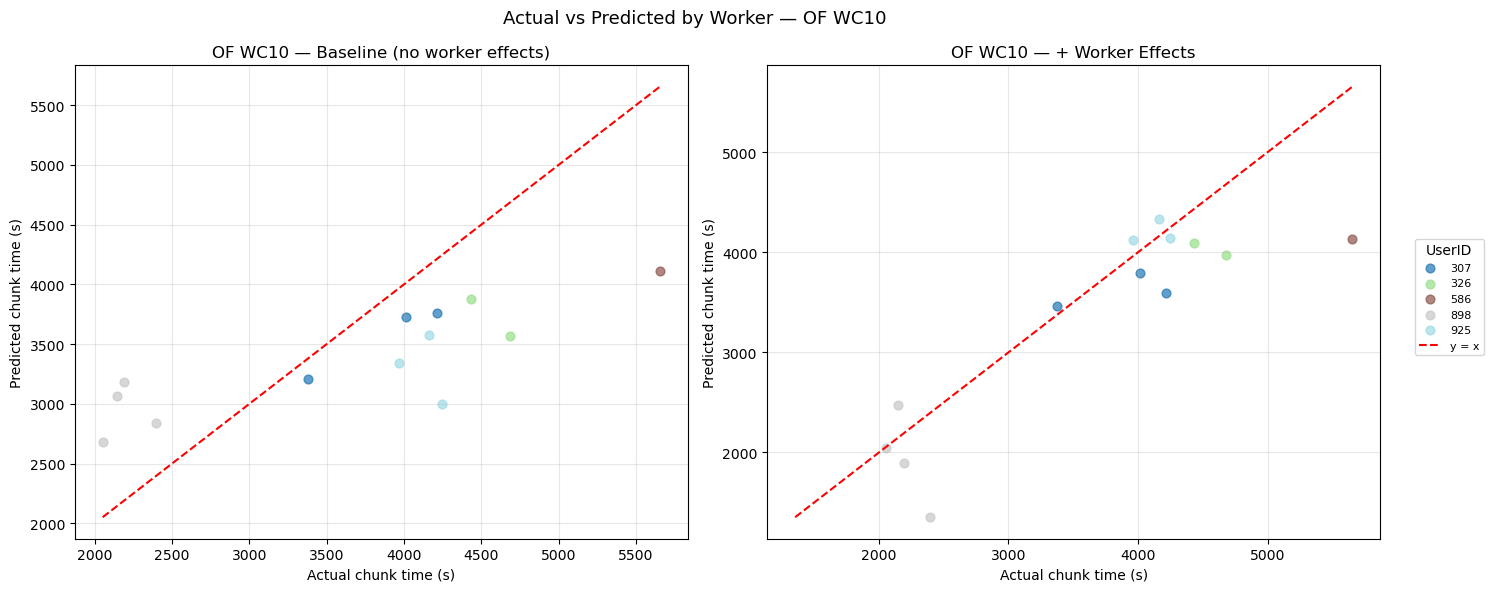

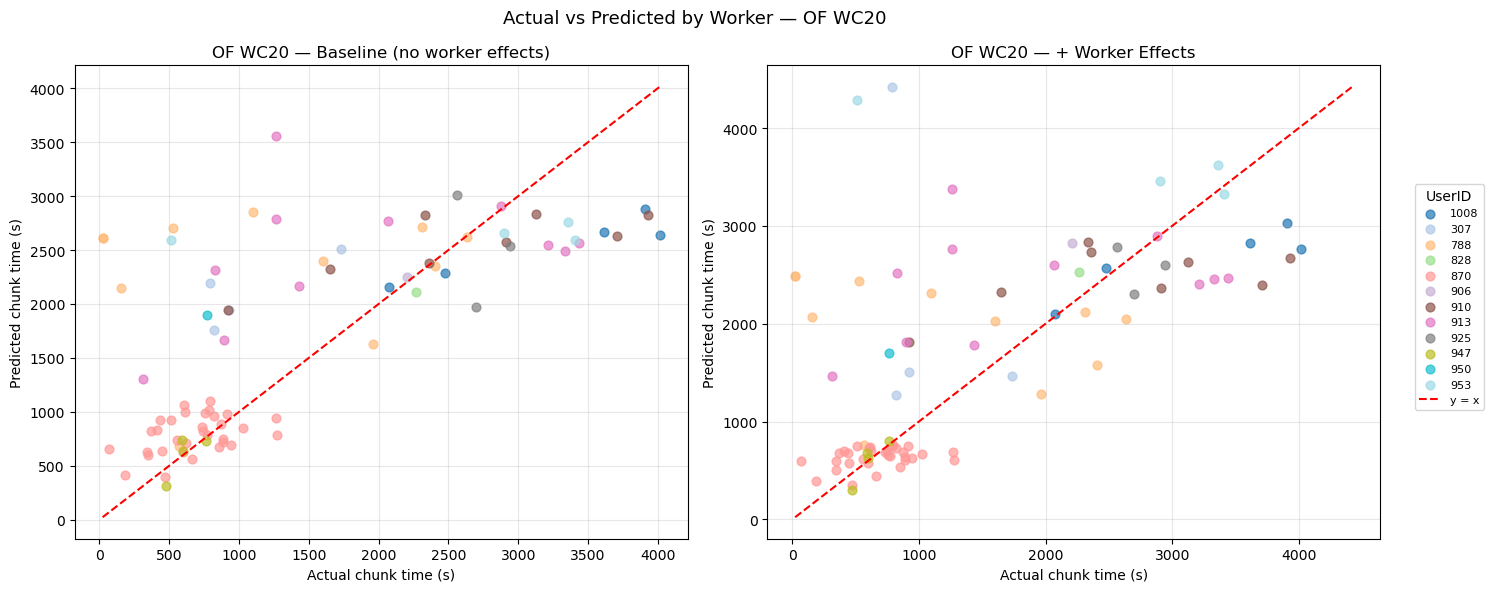

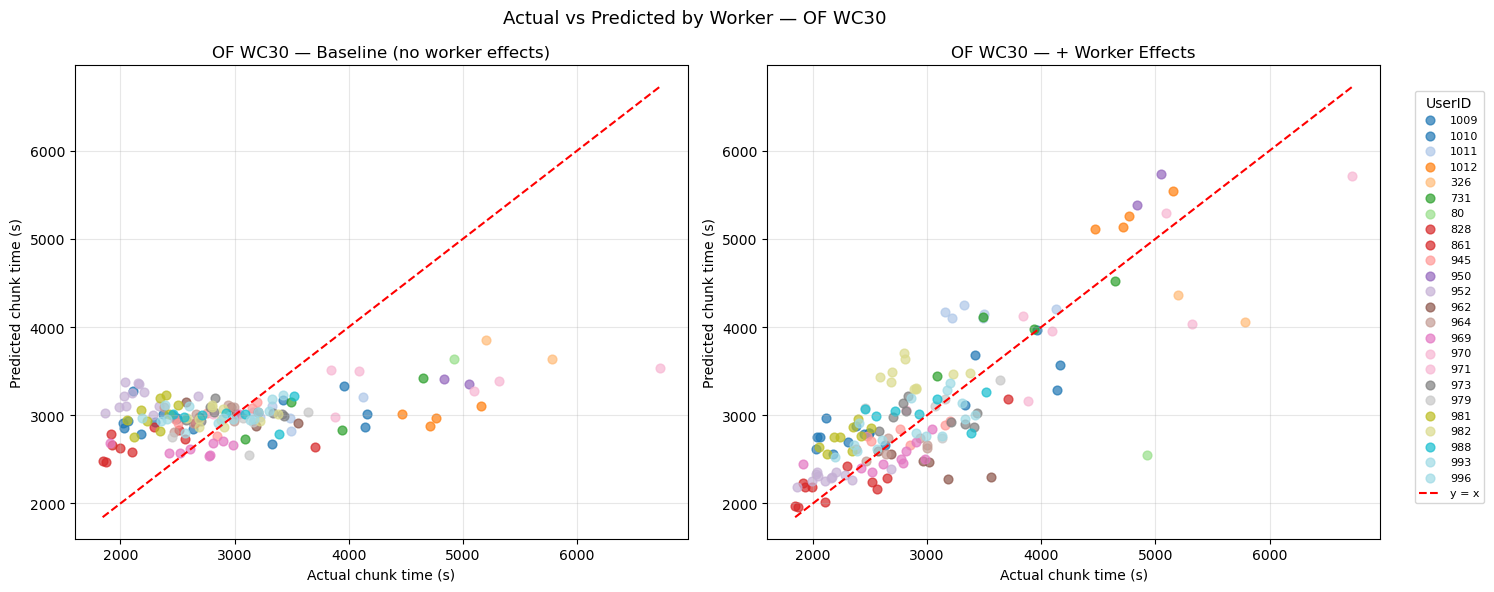

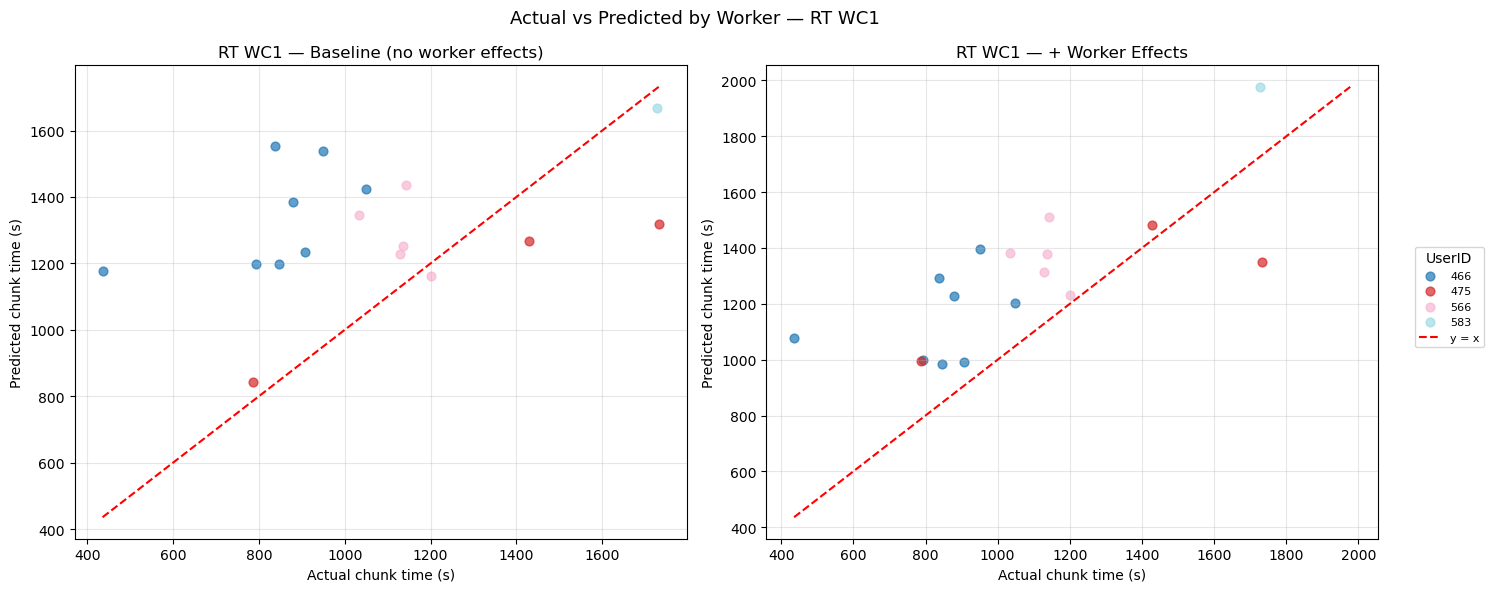

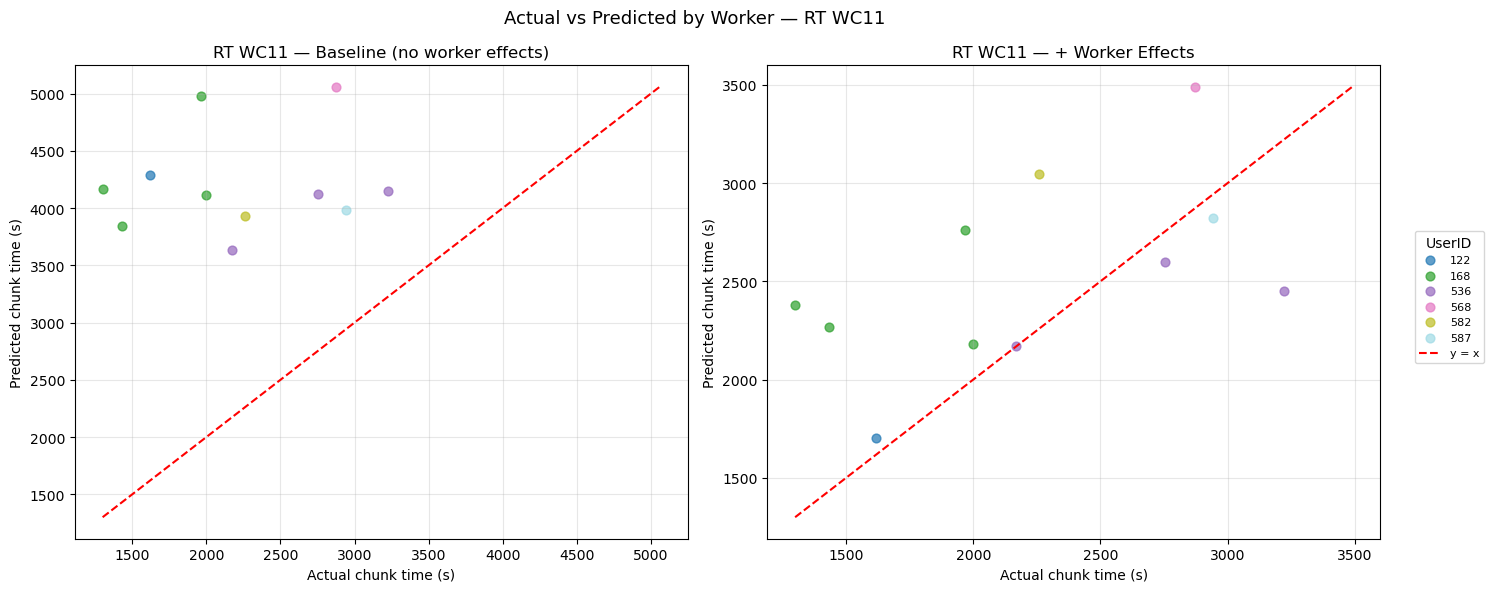

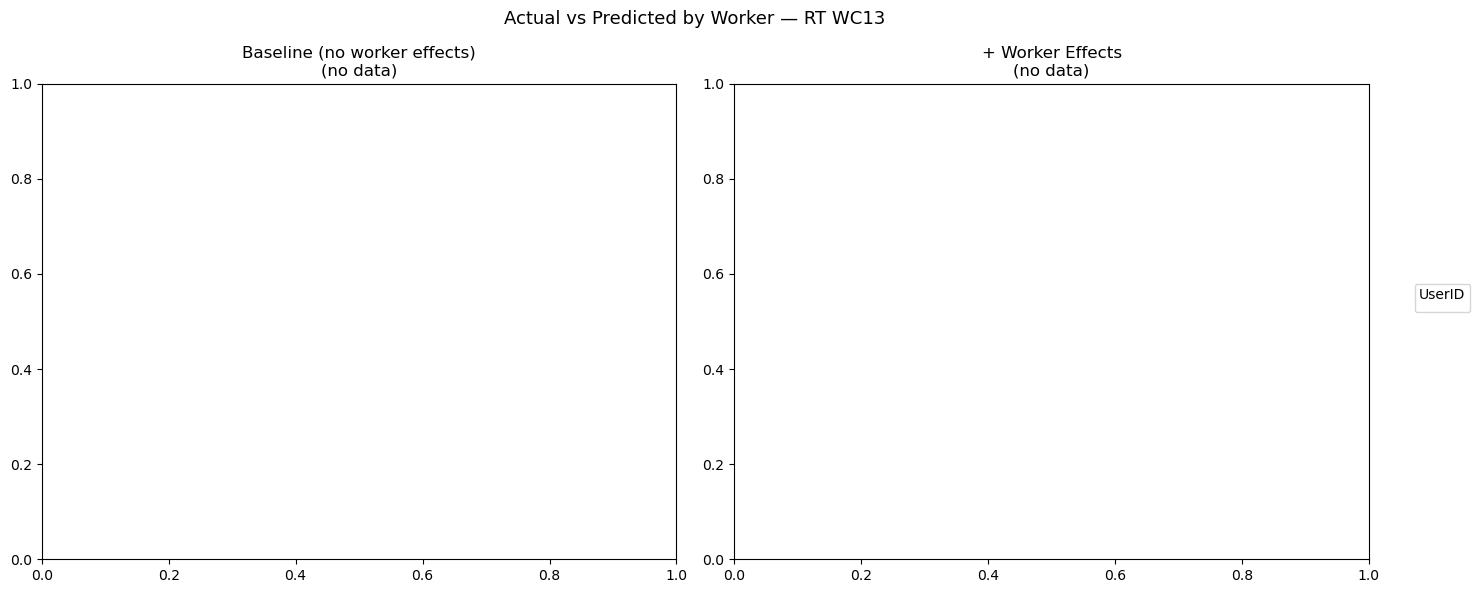

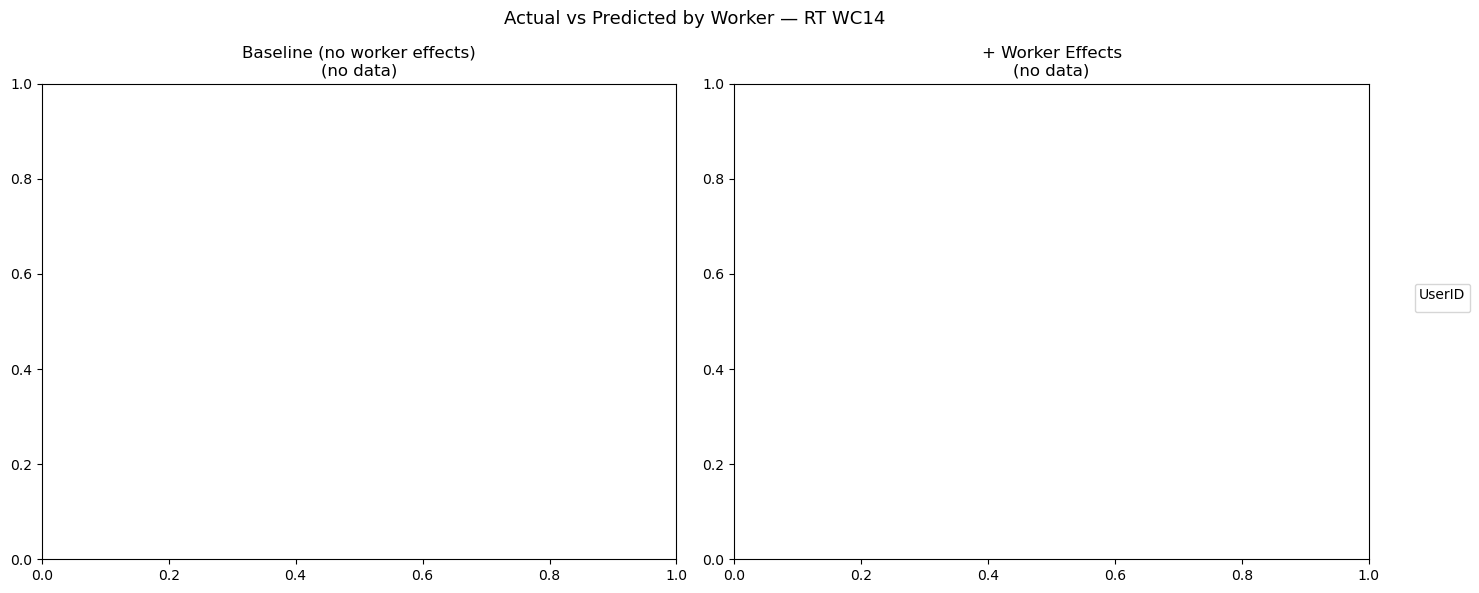

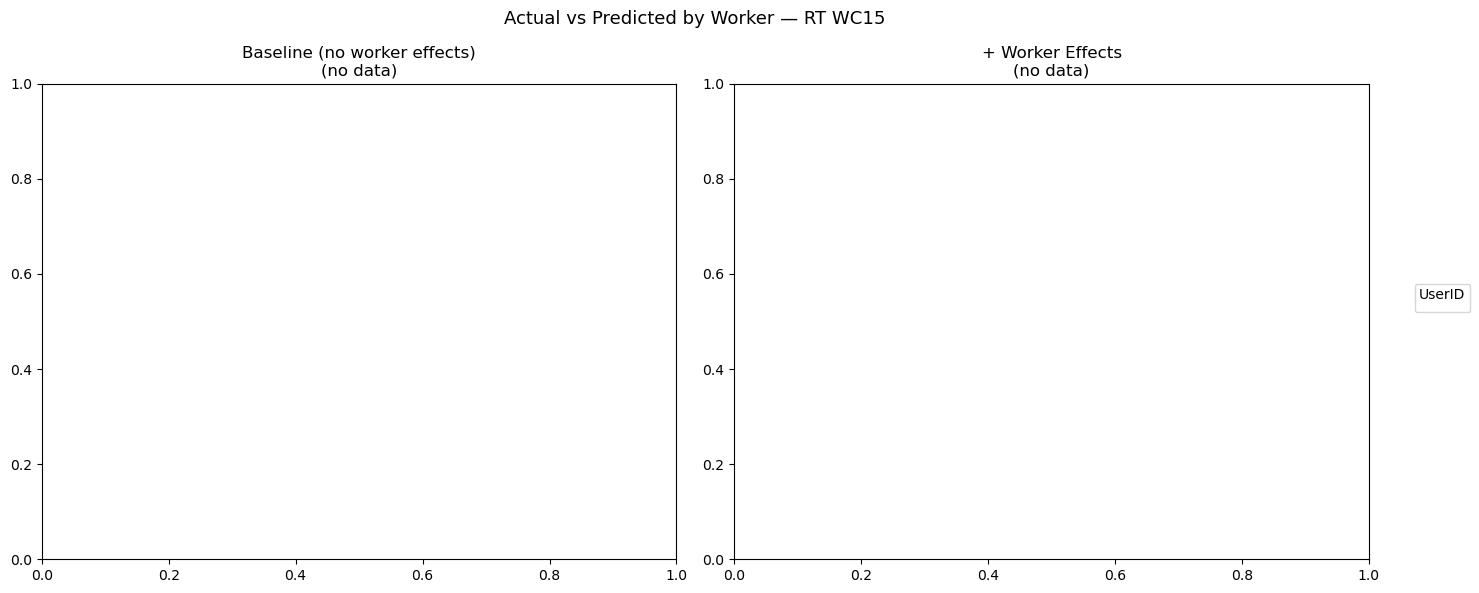

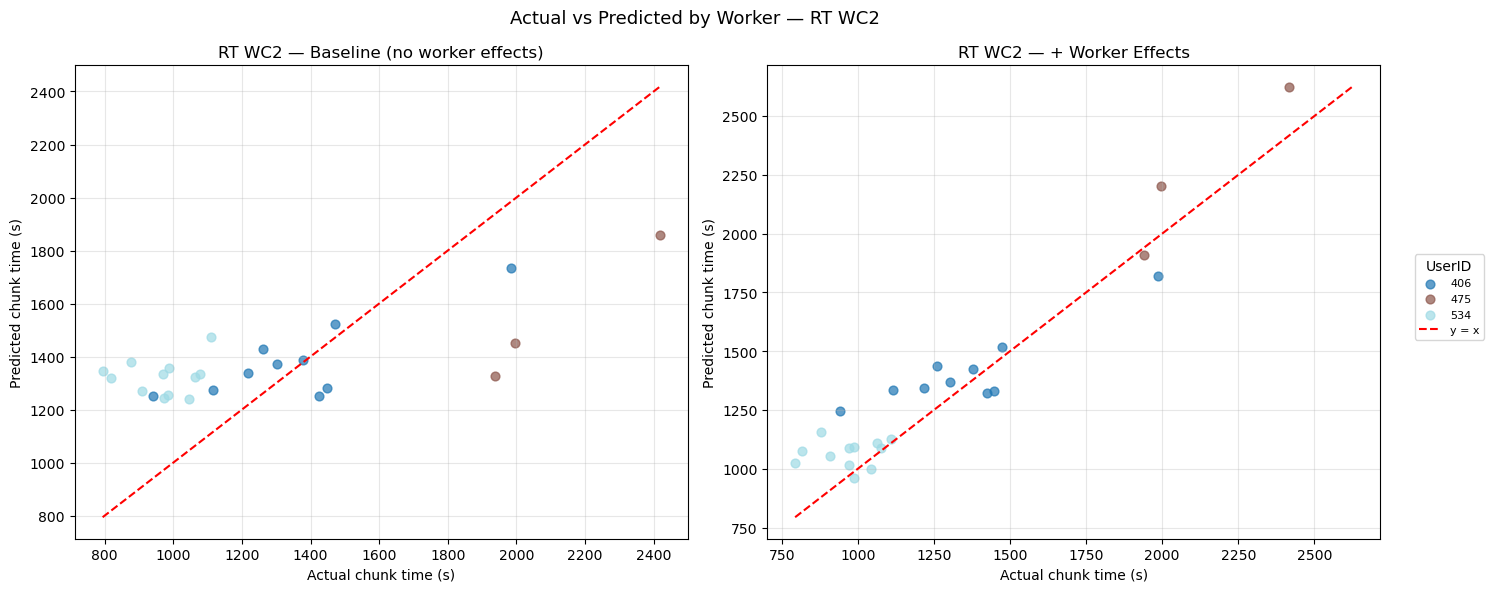

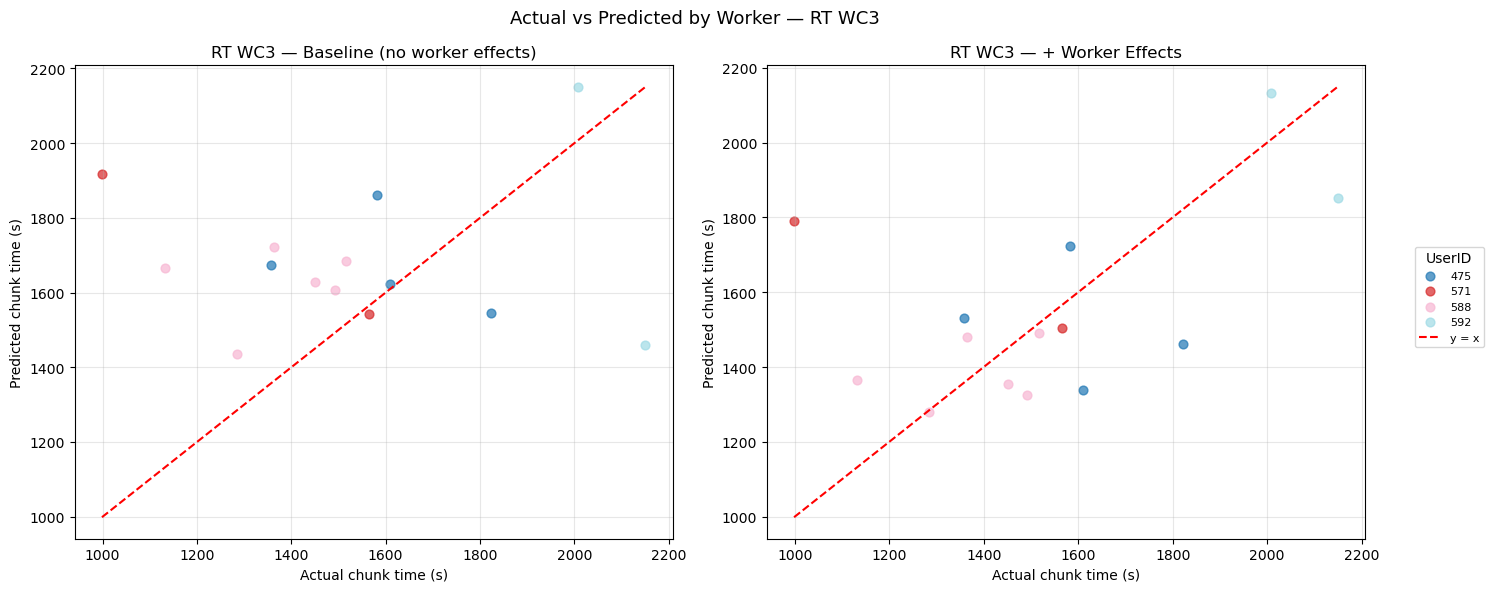

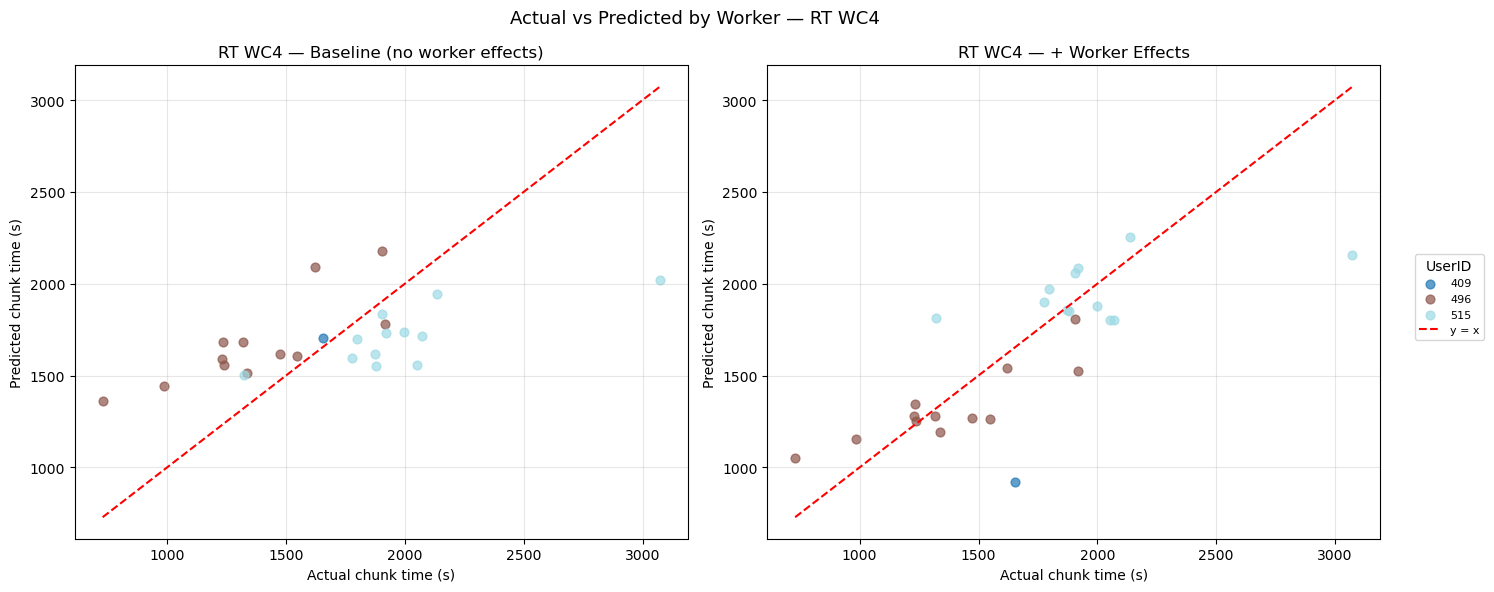

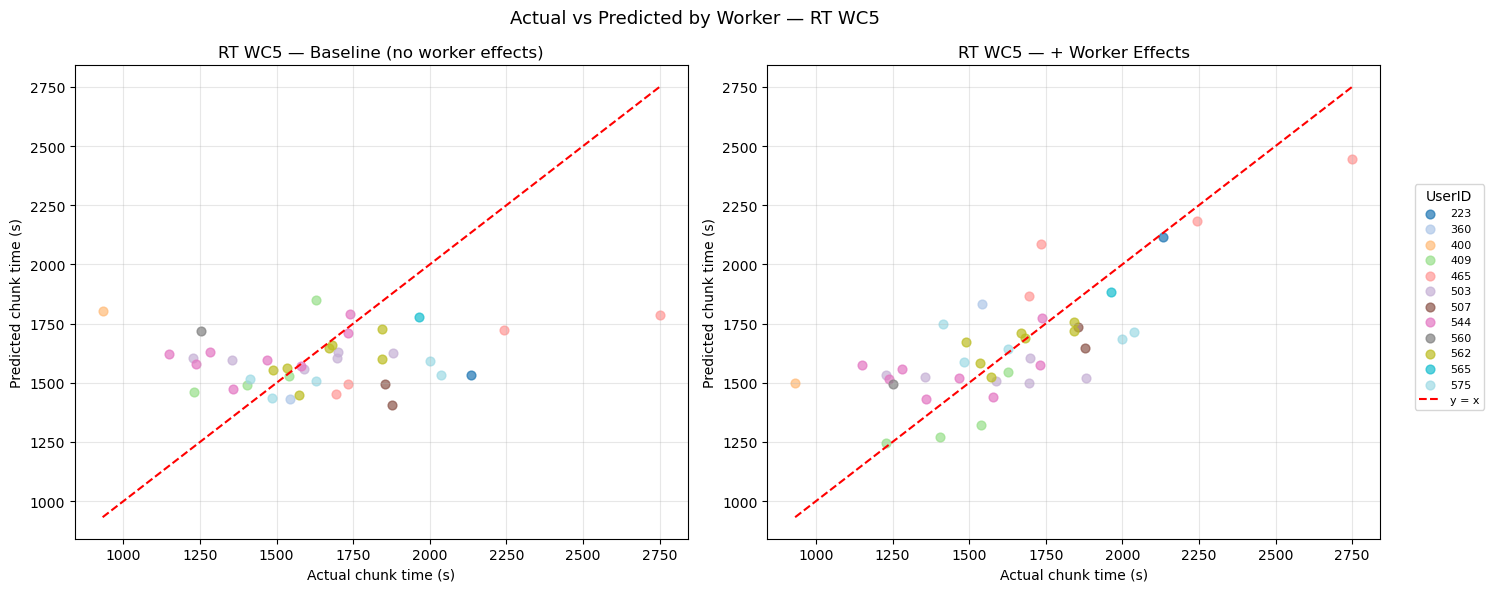

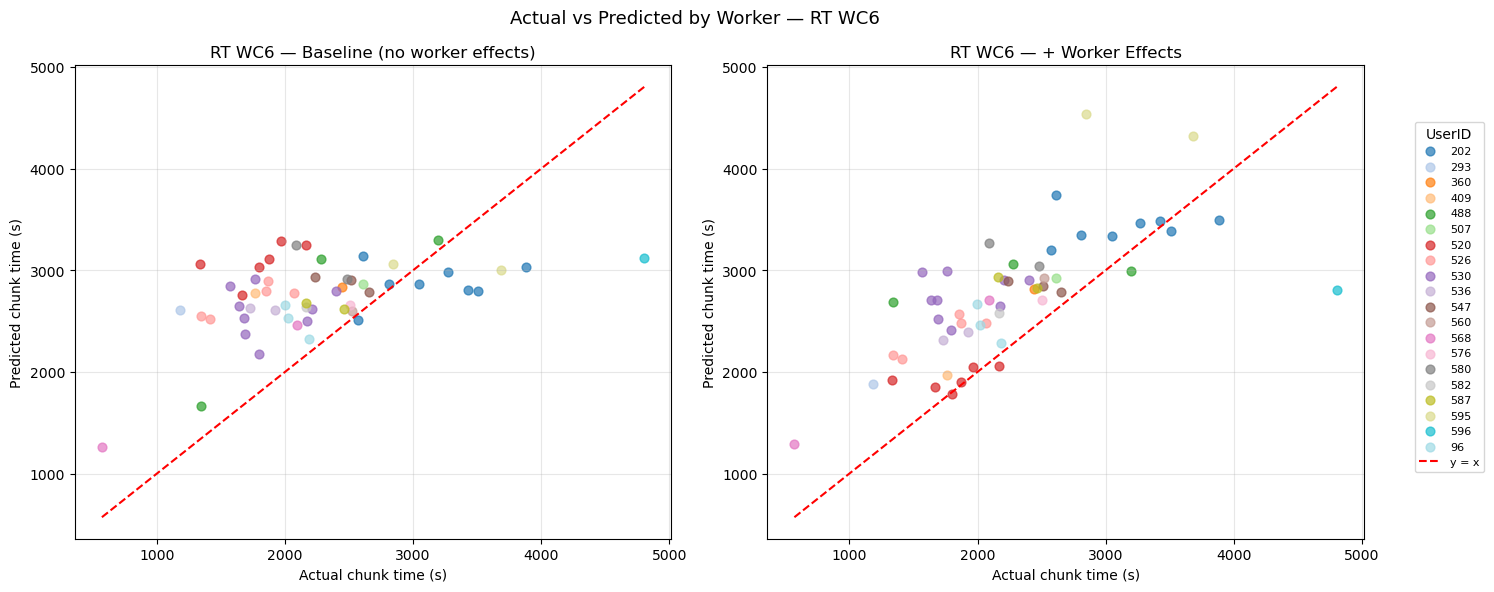

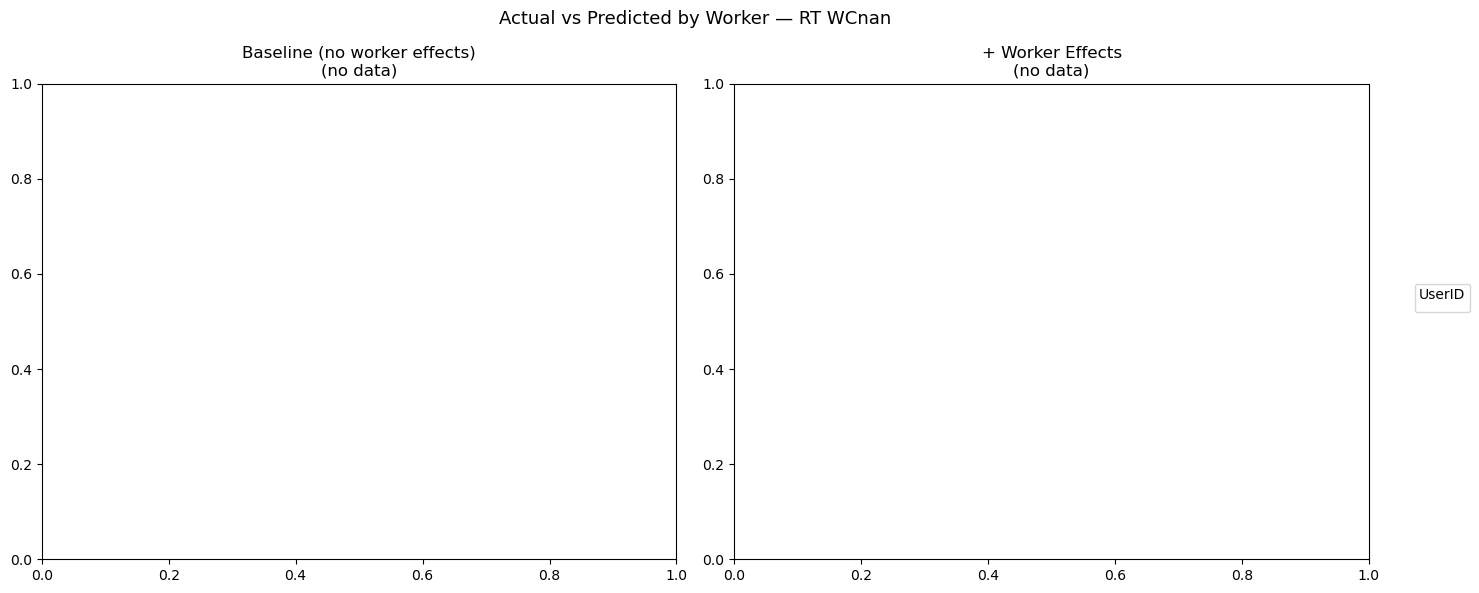

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_actual_vs_predicted_by_worker(block_detail_df, block_detail_w_df, warehouse, wc):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, df, title in [
        (axes[0], block_detail_df,   "Baseline (no worker effects)"),
        (axes[1], block_detail_w_df, "+ Worker Effects"),
    ]:
        df_wc = df[(df["Warehouse"] == warehouse) & (df["WorkCode"] == wc)].copy()
        if df_wc.empty:
            ax.set_title(f"{title}\n(no data)")
            continue

        workers = df_wc["UserID"].unique()
        colors  = cm.tab20(np.linspace(0, 1, len(workers)))
        color_map = dict(zip(workers, colors))

        for worker in workers:
            sub = df_wc[df_wc["UserID"] == worker]
            ax.scatter(sub["actual_time"], sub["pred"],
                       color=color_map[worker], alpha=0.7, s=40, label=str(worker))

        lims = [
            min(df_wc["actual_time"].min(), df_wc["pred"].min()),
            max(df_wc["actual_time"].max(), df_wc["pred"].max()),
        ]
        ax.plot(lims, lims, "r--", linewidth=1.5, label="y = x")
        ax.set_xlabel("Actual chunk time (s)")
        ax.set_ylabel("Predicted chunk time (s)")
        ax.set_title(f"{warehouse} WC{wc} — {title}")
        ax.grid(True, alpha=0.3)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, title="UserID",
               bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=8)
    plt.suptitle(f"Actual vs Predicted by Worker — {warehouse} WC{wc}", fontsize=13)
    plt.tight_layout()
    plt.show()


# Run for each warehouse and WorkCode you care about
for wh, data in warehouses.items():
    for wc in data["WORKCODES"]:
        plot_actual_vs_predicted_by_worker(
            data["block_detail_df"],
            data["block_detail_w_df"],
            wh, wc
        )

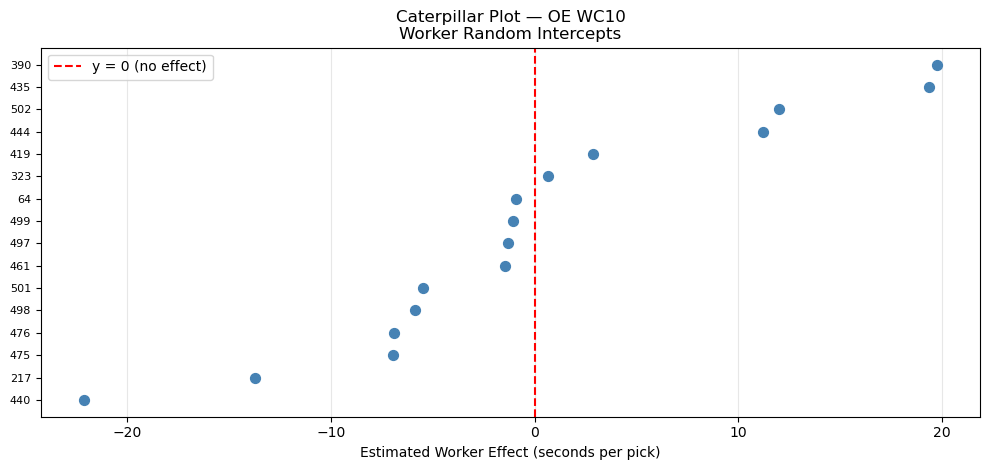

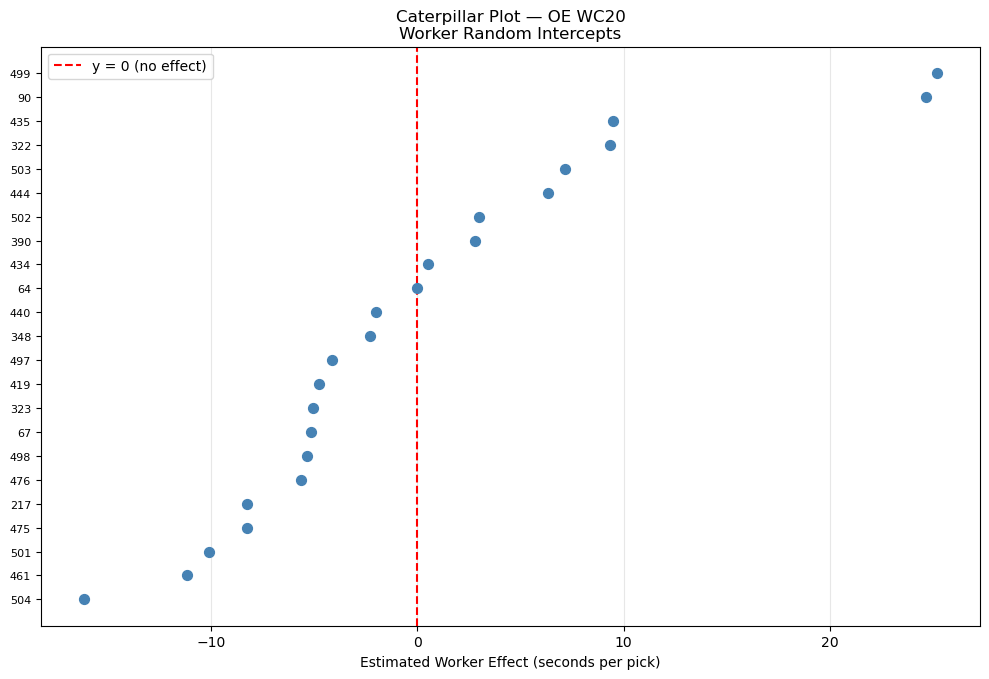

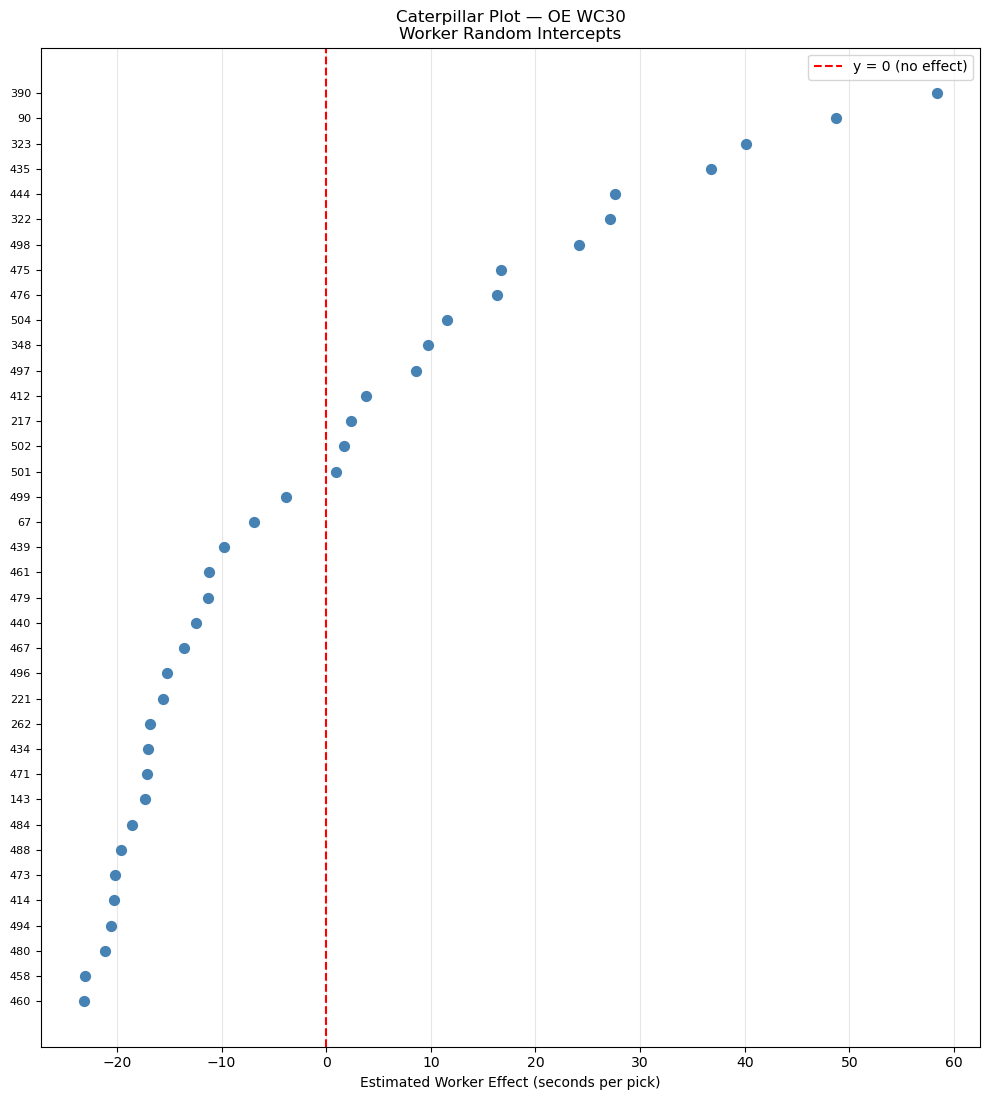

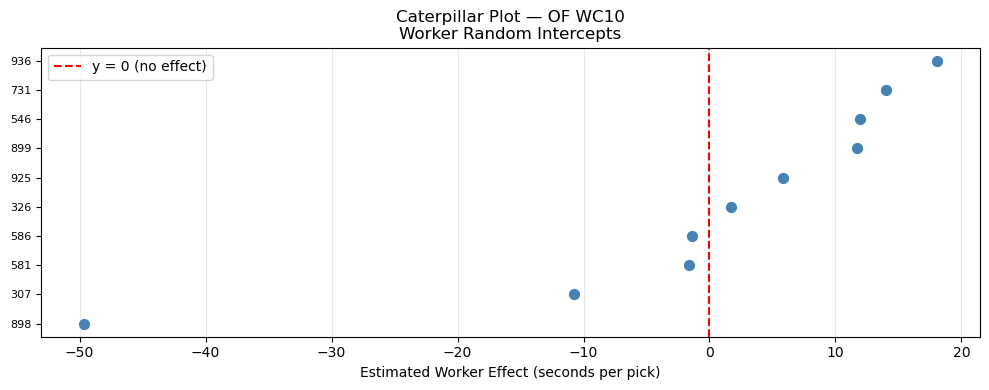

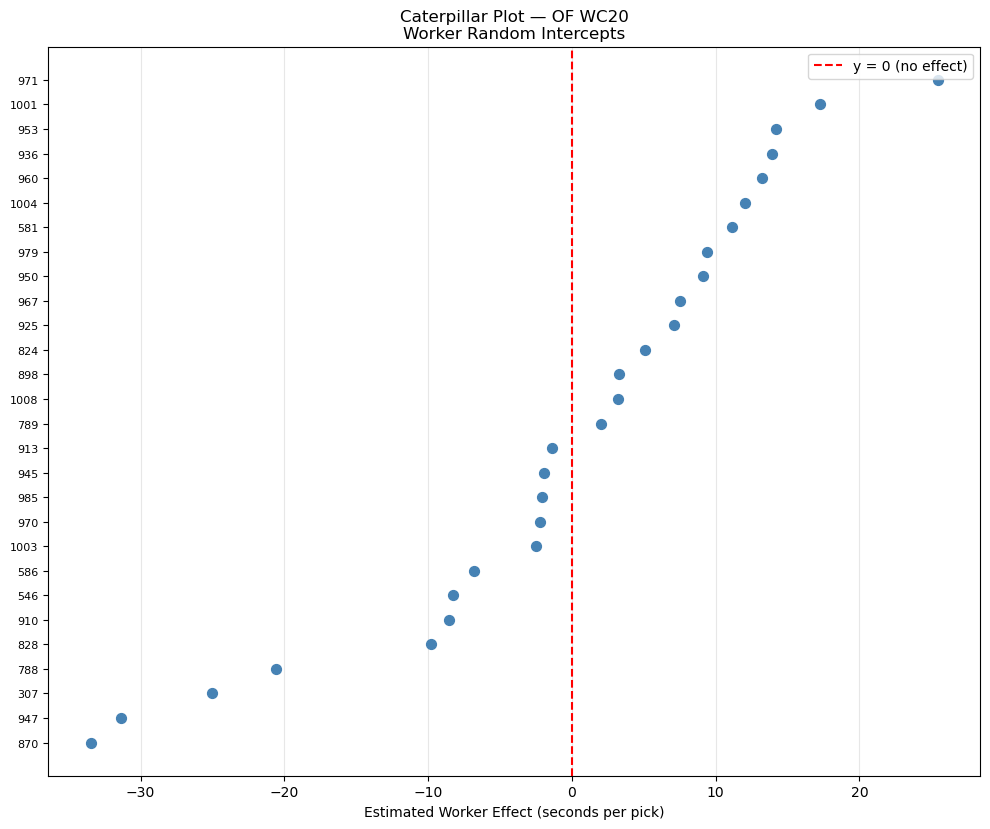

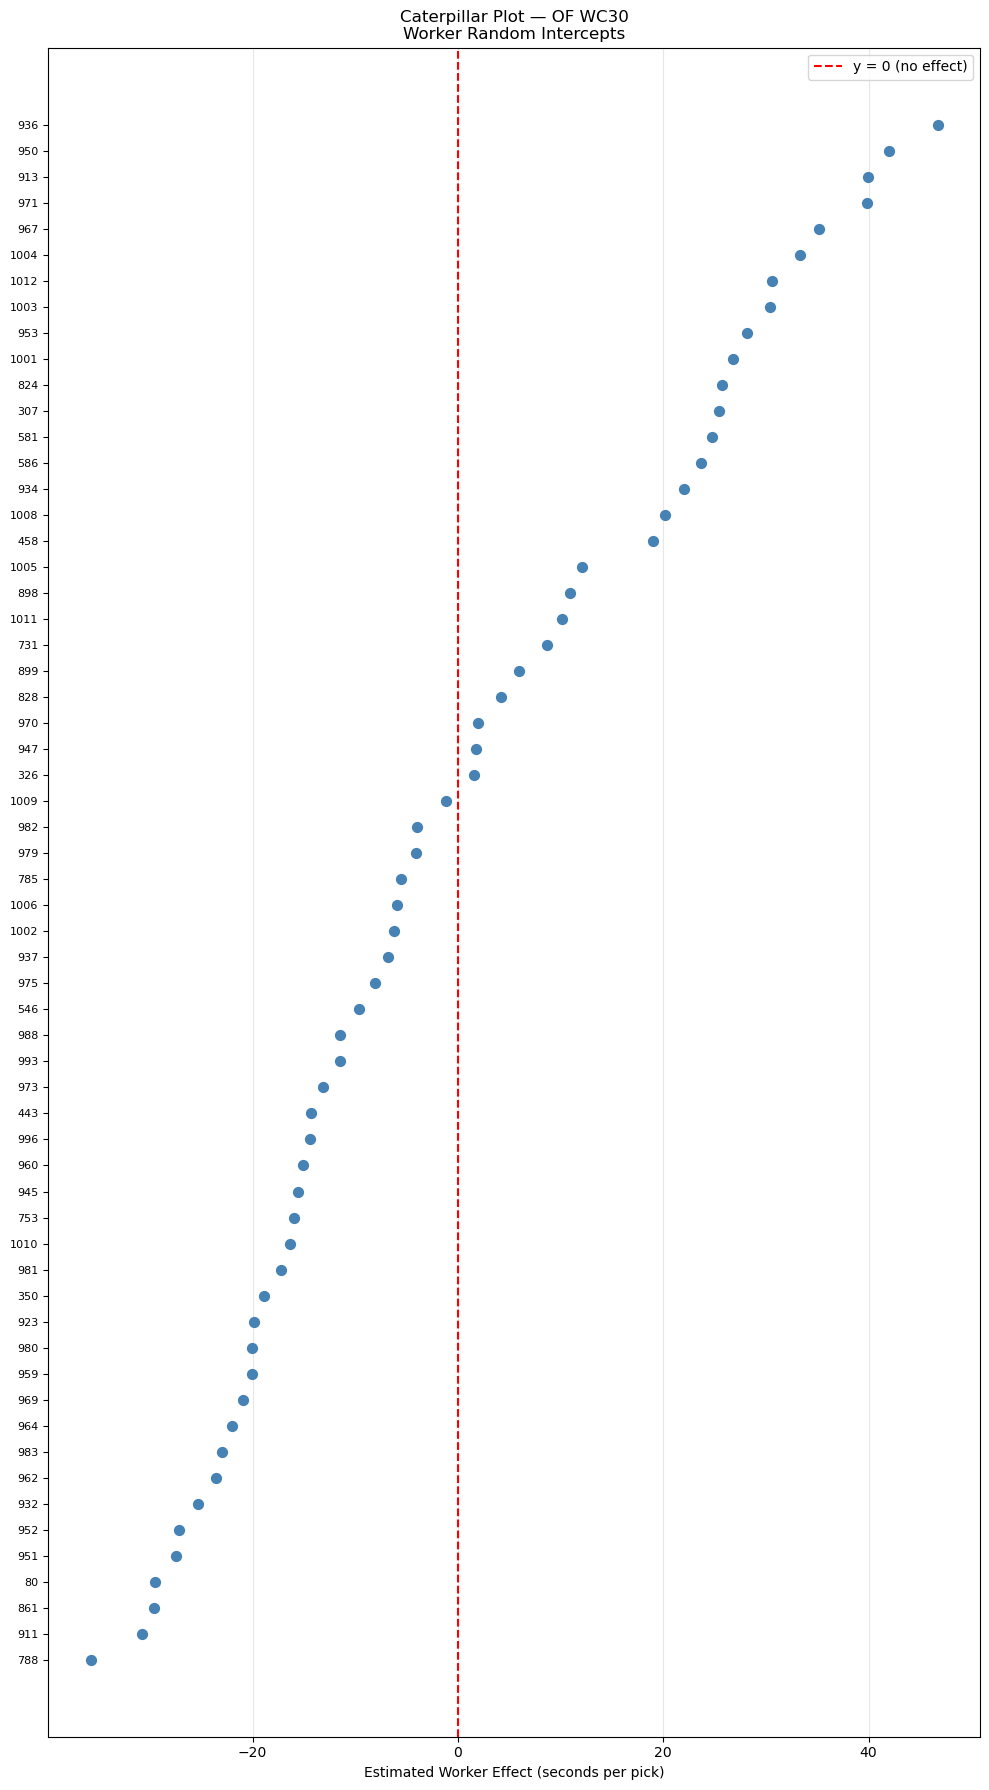

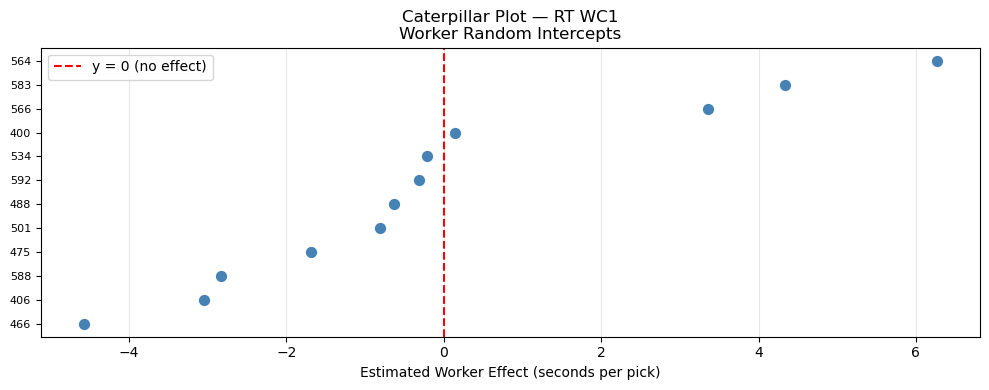

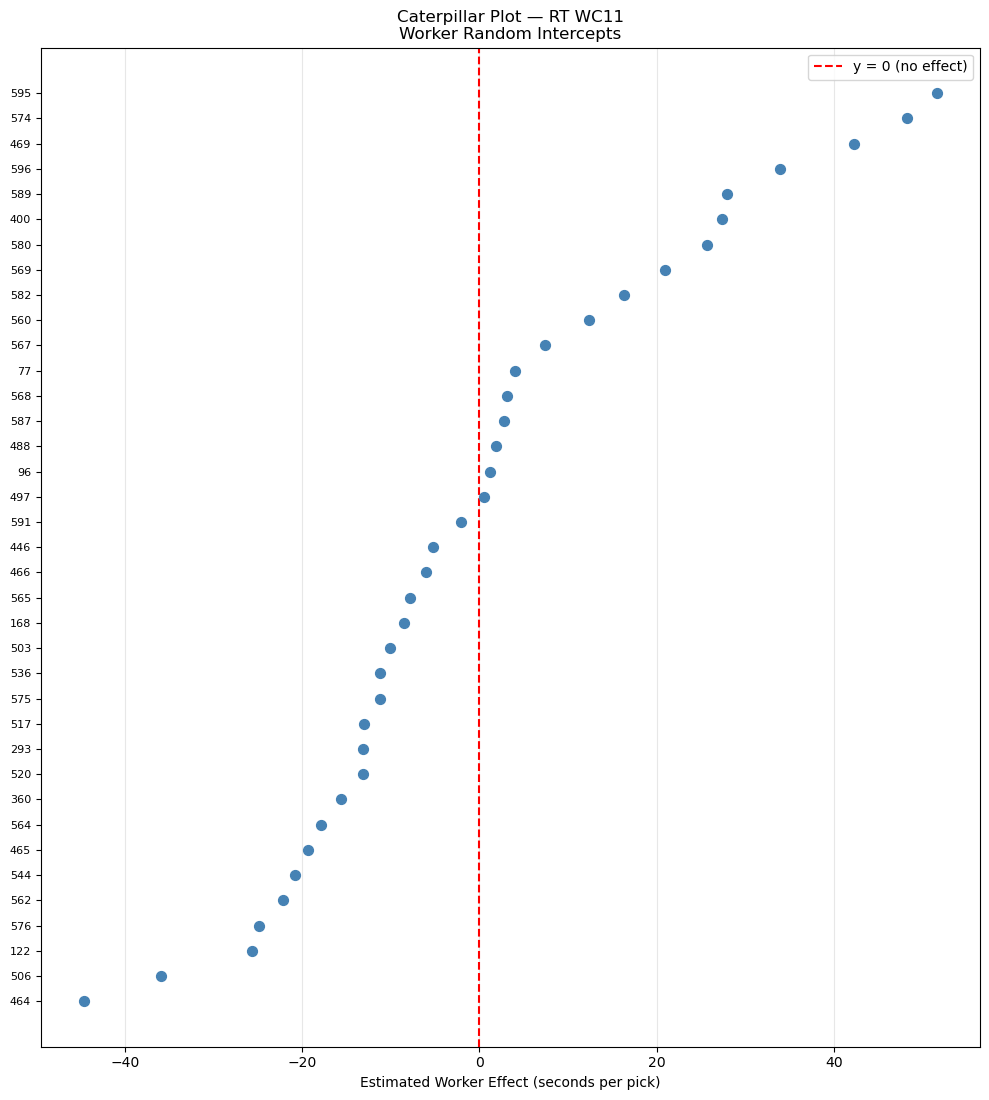

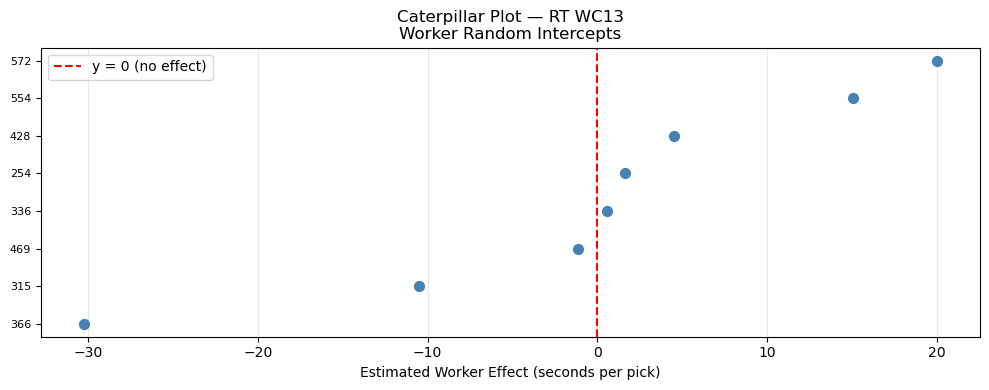

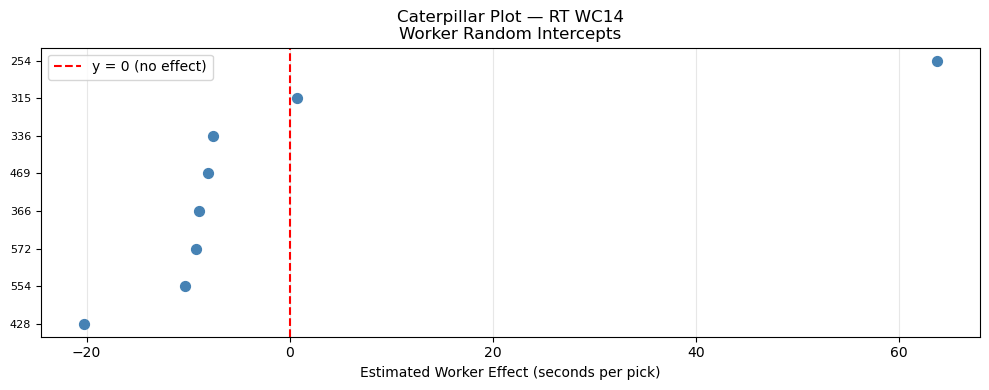

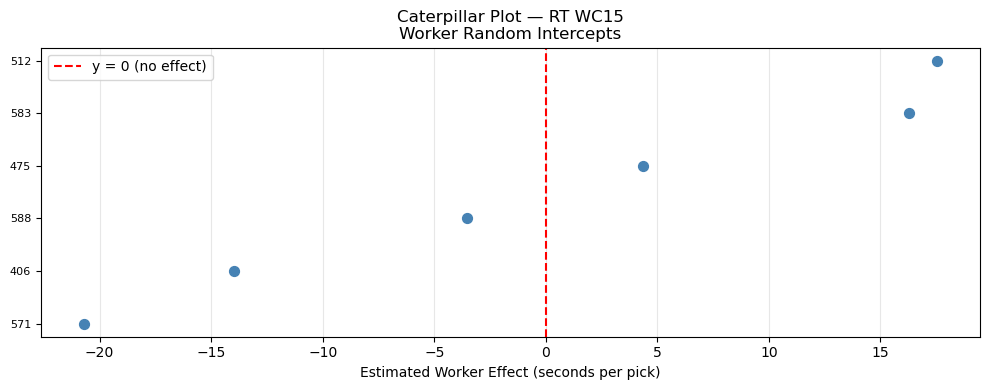

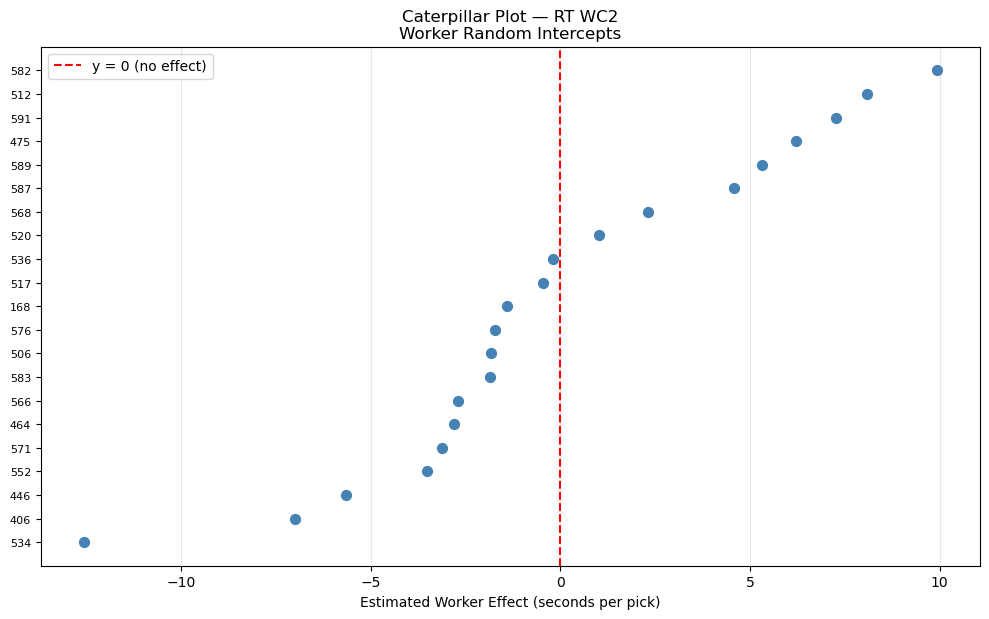

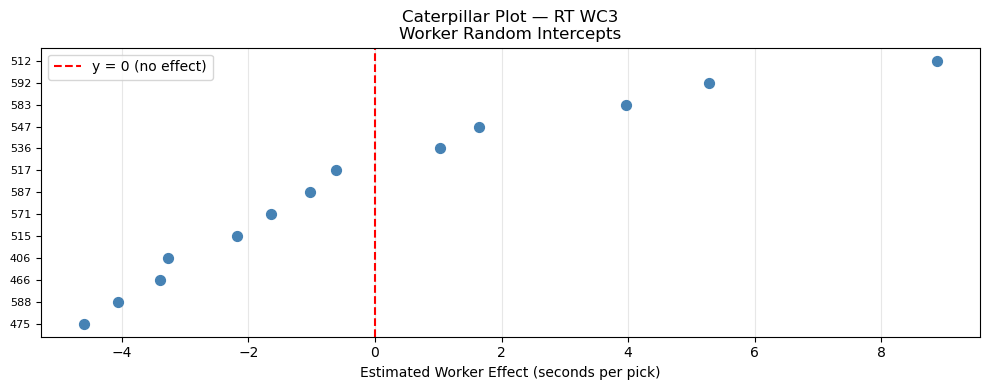

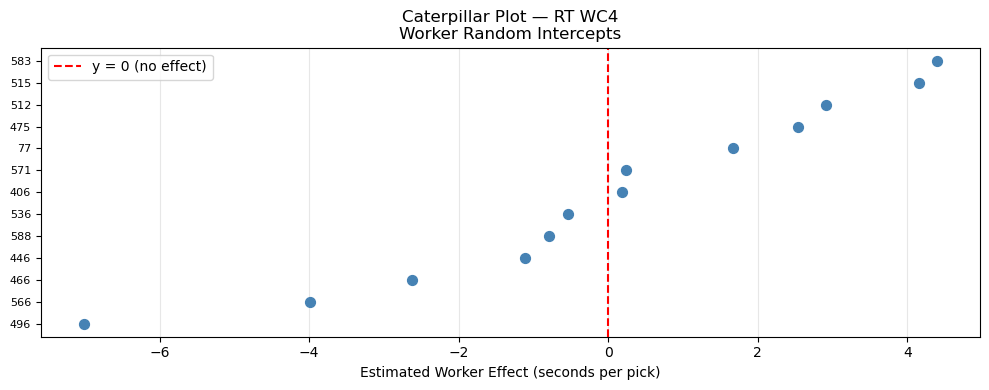

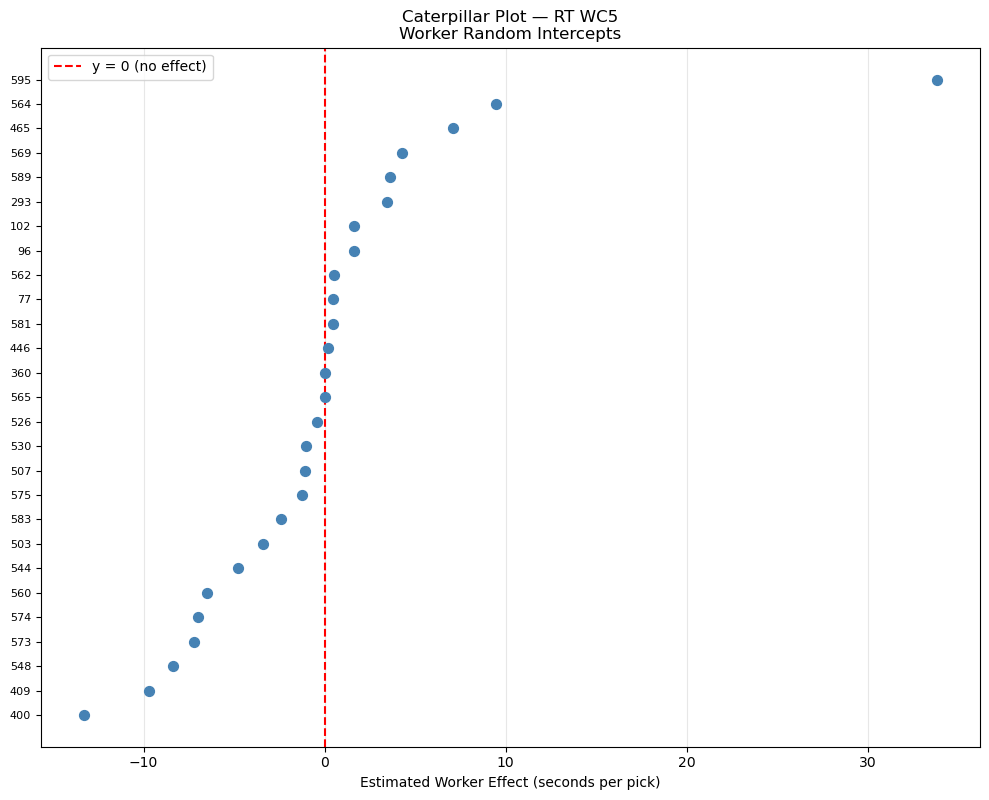

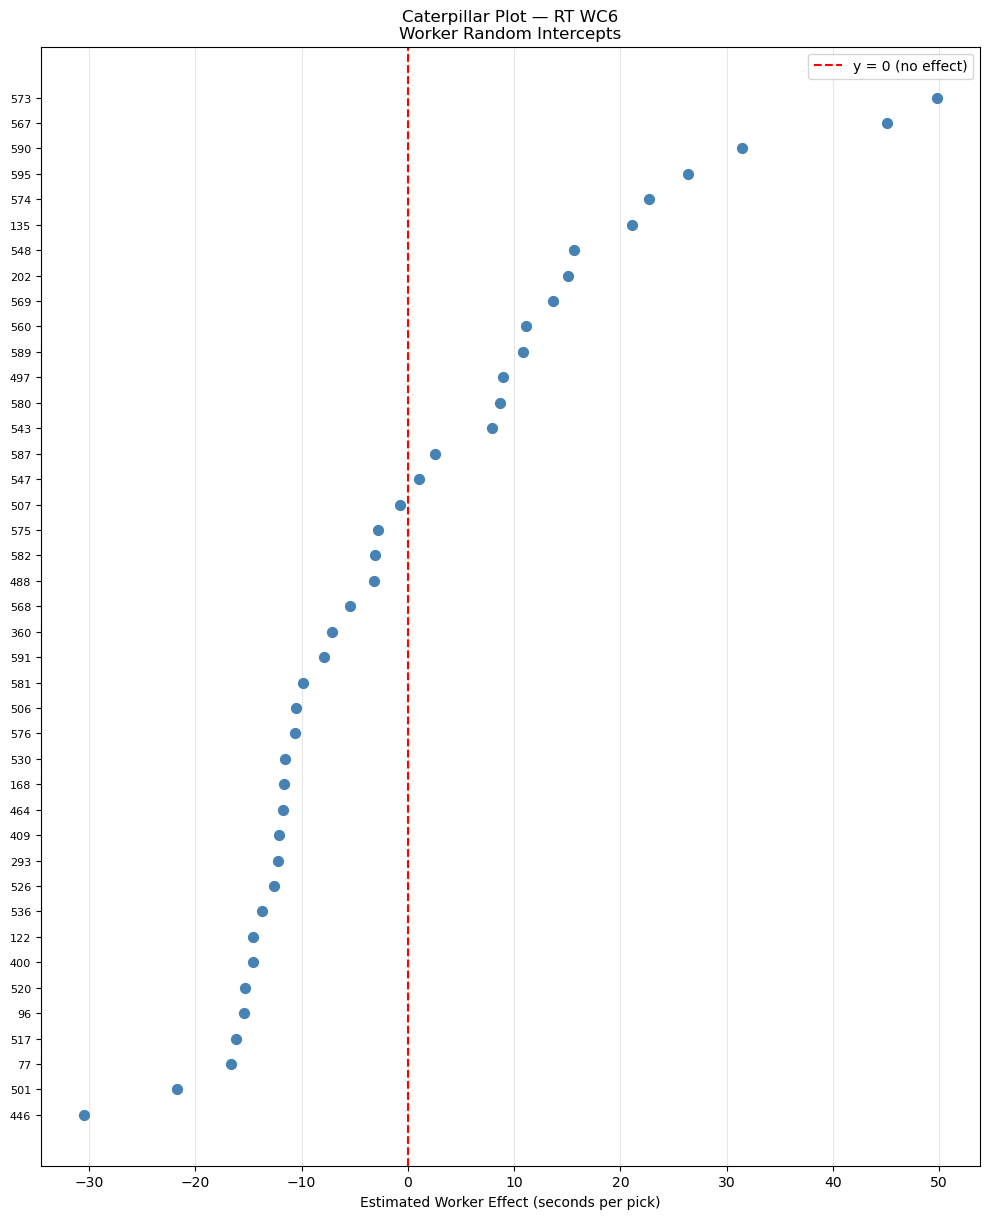

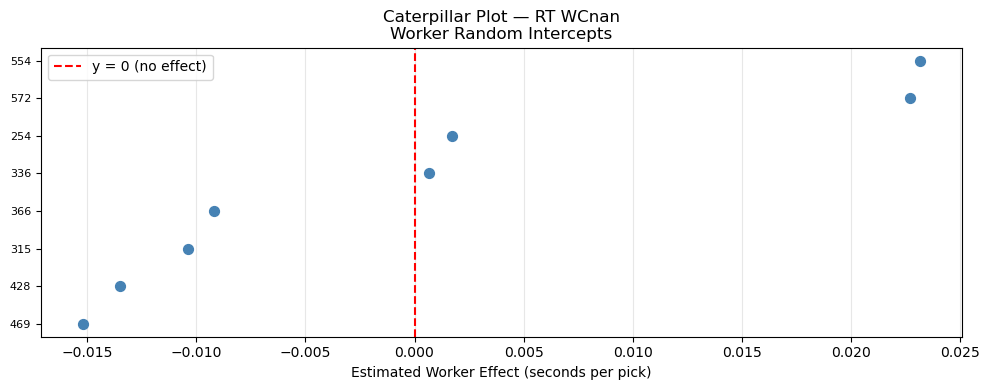

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf

def plot_caterpillar(worker_effects_df, warehouse, wc):
    subset = worker_effects_df[worker_effects_df["WorkCode"] == wc].copy()
    subset = subset.sort_values("worker_effect").reset_index(drop=True)
    
    if subset.empty:
        print(f"No worker effects for {warehouse} WC{wc}")
        return

    fig, ax = plt.subplots(figsize=(10, max(4, len(subset) * 0.3)))

    y_pos = np.arange(len(subset))
    ax.scatter(subset["worker_effect"], y_pos, zorder=3, color="steelblue", s=50)

    # Approximate CI using ±1.96 * SD of effects as a rough spread indicator
    #sd = subset["worker_effect"].std()
    #for i, row in subset.iterrows():
    #    ax.plot([row["worker_effect"] - 1.96 * sd,
    #             row["worker_effect"] + 1.96 * sd],
    #            [i, i], color="steelblue", alpha=0.4, linewidth=1.5)

    # y=0 line — the "no effect" reference
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="y = 0 (no effect)")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(subset["UserID"], fontsize=8)
    ax.set_xlabel("Estimated Worker Effect (seconds per pick)")
    ax.set_title(f"Caterpillar Plot — {warehouse} WC{wc}\nWorker Random Intercepts")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout()
    plt.show()


# Run for each warehouse and WorkCode
for wh, data in warehouses.items():
    for wc in data["WORKCODES"]:
        plot_caterpillar(data["worker_effects_df"], wh, wc)